In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Gerekli kütüphaneler

df = pd.read_csv('../data/Telco-Customer-Churn-Cleaned.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (7032, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_year
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-3 Years
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3-4 Years
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year


### 1. Categorical Analysis - Contract Type vs. Churn

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


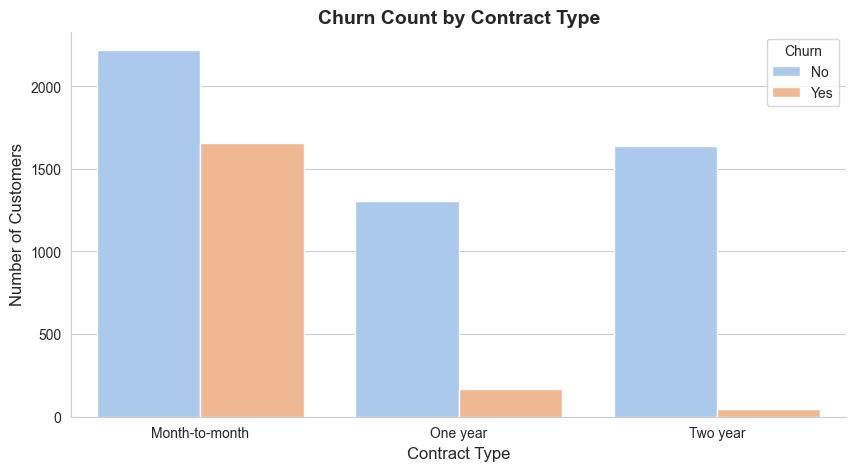

In [4]:
contract_cross = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_cross)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

sns.countplot(x='Contract', hue='Churn', data=df, palette='pastel')
plt.title('Churn Count by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
sns.despine()

plt.show()

A bivariate analysis was conducted using a countplot and cross-tabulation to evaluate how different contract structures influence customer loyalty.

### The Vulnerability of Month-to-Month Contracts
Customers on month-to-month contracts exhibit an alarmingly high churn rate, reaching approximately 42%. Although the absolute number of retained customers in this category remains high due to class imbalance, the proportion of defection confirms that non-contractual subscribers represent the primary driver of customer attrition.

### The Long-Term Contract Retention Shield
In stark contrast, customers tied to one-year and two-year commitments show exceptional stability. The churn rate drops significantly for one-year contracts and hits a rock-bottom floor of nearly 2% for two-year contracts. Financial commitments effectively neutralize price sensitivity and competitor poaching.

### Strategic Action Item
The organization must actively disincentivize month-to-month sign-ups. The marketing and sales teams should focus on auto-converting monthly subscribers into longer-term commitments by offering micro-discounts or bundled service rewards upon upgrading to a yearly plan.

In [11]:
from scipy.stats import chi2_contingency

# Create a contingency table for Contract vs Churn
contingency_matrix = pd.crosstab(df['Contract'], df['Churn'])

# Run the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_matrix)

print(f"--- Statistical Validation for Contract vs Churn ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}") # If p < 0.05, the relationship is statistically significant!

--- Statistical Validation for Contract vs Churn ---
Chi-Square Statistic: 1179.5458
P-value: 7.3262e-257


### 2. Multivariate Profiling - Interaction of Contract, TechSupport, and Churn

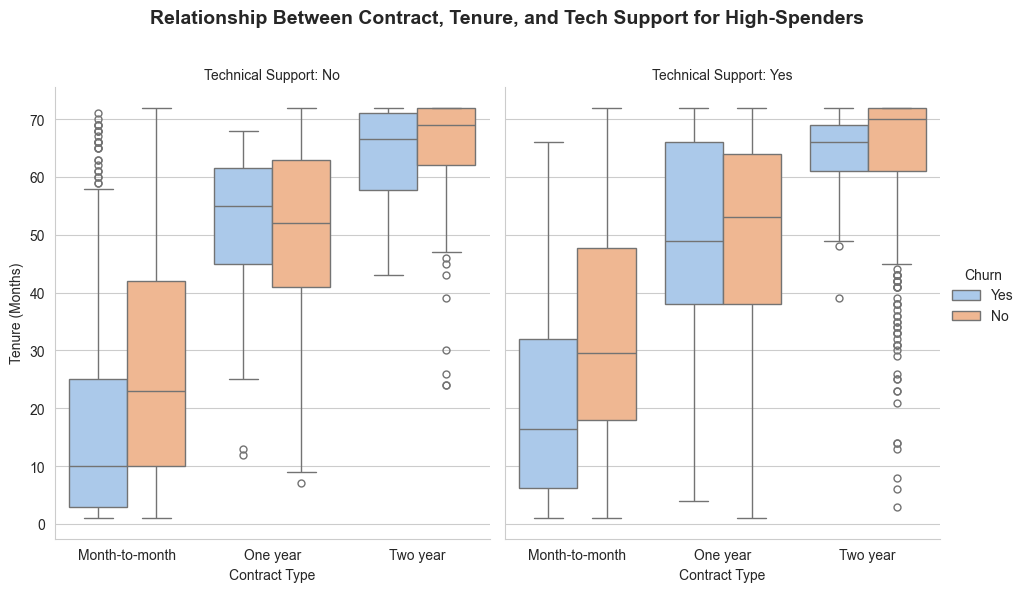

In [16]:
# 1. Filter the high-value premium segment ("Monthly Charges" > $70)
high_spenders = df[df['MonthlyCharges'] > 70]

# 2. Plot the multi-dimensional boxplot grid using catplot
g = sns.catplot(
    data=high_spenders,
    x="Contract",
    y="tenure",
    hue="Churn",
    col="TechSupport",  # Splits the screen into vertical panels based on TechSupport status
    kind="box",
    palette="pastel",
    height=6,
    aspect=0.8
)

# Customize and polish the plot layout
g.set_axis_labels("Contract Type", "Tenure (Months)")
g.set_titles("Technical Support: {col_name}")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Relationship Between Contract, Tenure, and Tech Support for High-Spenders",
               fontsize=14, fontweight='bold')

plt.show()

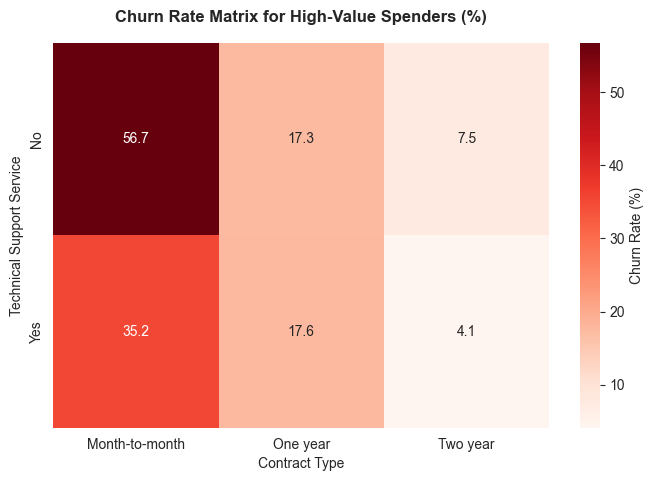

In [17]:
# 1. Create a pivot table to calculate the precise churn rate (%) across segments
heatmap_data = high_spenders.pivot_table(
    index='TechSupport',
    columns='Contract',
    values='Churn',
    aggfunc=lambda x: (x == 'Yes').mean() * 100  # Calculates the churn rate percentage
)

# 2. Plot the professional matrix heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Reds",
    fmt=".1f",
    cbar_kws={'label': 'Churn Rate (%)'}
)

# Adjust titles and axis labels to global corporate standards
plt.title("Churn Rate Matrix for High-Value Spenders (%)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Contract Type")
plt.ylabel("Technical Support Service")

plt.show()


A specialized percentage bar chart was deployed to isolate the joint impact of contract structures and technical assistance on premium customer retention.

### The Strategic Value of Technical Support in Volatile Segments
The visualization clearly isolates TechSupport as a massive retention lever, but strictly within month-to-month accounts. For non-contractual high-spenders, providing technical support slashes the churn rate significantly. This proves that operational assistance acts as an artificial retention anchor when formal contractual anchors are absent.

### Contract Dominance and Feature Insensitivity
For customers on one-year and two-year commitments, the presence of TechSupport is statistically indecisive. The churn bars remain uniformly flat and low regardless of service attachment. This confirms that long-term contract structures represent a dominant loyalty feature, rendering secondary support services redundant from a pure retention standpoint.

### Strategic Action Item
The customer success team should systematically bundle free or heavily discounted TechSupport packages into month-to-month high-tier plans during onboarding. Since long-term contract users are already shielded from churn, secondary support resources should be prioritized toward high-value monthly accounts to maximize return on investment.

### 3. Executive Insights - Advanced Customer Profiling Analysis

In [18]:
# 1. Filter the high-value premium segment ("Monthly Charges" > $70)
high_spenders = df[df['MonthlyCharges'] > 70]

# 2. Compute Churn Rate and Average Tenure across infrastructure, tech support, and contract segments
profile_table = high_spenders.groupby(['InternetService', 'TechSupport', 'Contract']).agg(
    Customer_Count=('Churn', 'count'),
    Churn_Rate=('Churn', lambda x: (x == 'Yes').mean() * 100),
    Average_Tenure=('tenure', 'mean')
).reset_index()

# 3. Sort the final table by Churn Rate in descending order for better readability
print("--- Detailed Profile of High-Value Spenders ($70+) ---")
print(profile_table.sort_values(by='Churn_Rate', ascending=False).to_string(index=False))

--- Detailed Profile of High-Value Spenders ($70+) ---
InternetService TechSupport       Contract  Customer_Count  Churn_Rate  Average_Tenure
    Fiber optic          No Month-to-month            1685   57.151335       21.043917
    Fiber optic         Yes Month-to-month             332   38.855422       28.629518
    Fiber optic         Yes       One year             226   20.353982       52.451327
            DSL          No Month-to-month              20   20.000000       22.800000
    Fiber optic          No       One year             313   18.530351       51.843450
            DSL         Yes Month-to-month              60   15.000000       23.183333
            DSL         Yes       One year             127   12.598425       44.464567
            DSL          No       One year              51    9.803922       42.980392
    Fiber optic          No       Two year             120    8.333333       65.983333
    Fiber optic         Yes       Two year             308    6.818182     

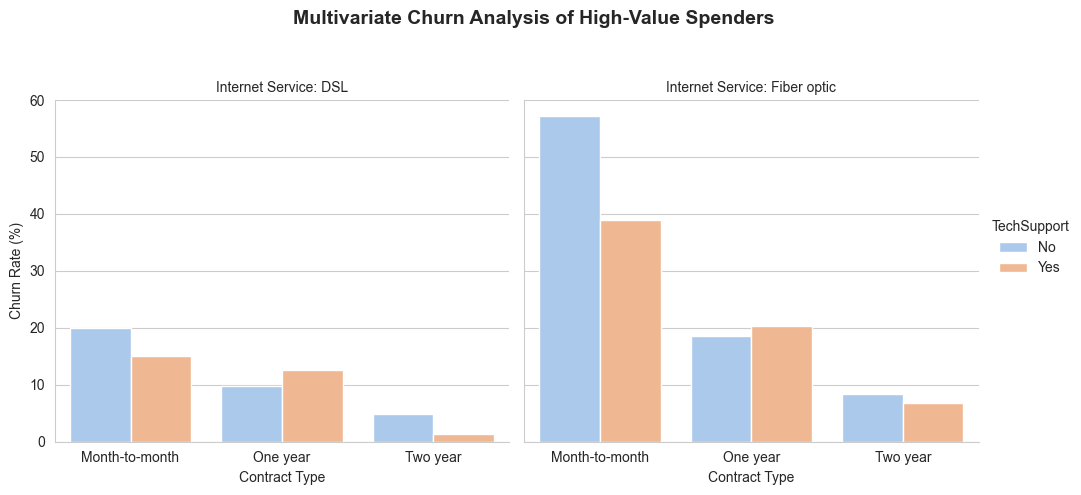

In [19]:
# Set a clean background style using Seaborn
sns.set_style("whitegrid")

# Plot Churn Rates (%) directly from profile_table
g = sns.catplot(
    data=profile_table,
    x="Contract",
    y="Churn_Rate",
    hue="TechSupport",
    col="InternetService",  # Splits the screen into Fiber and DSL panels
    kind="bar",             # Draws the Churn_Rate percentage from the table as bars
    palette="pastel",
    height=5,
    aspect=1
)

# Adjust axis labels and plot titles
g.set_axis_labels("Contract Type", "Churn Rate (%)")
g.set_titles("Internet Service: {col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Multivariate Churn Analysis of High-Value Spenders", fontsize=14, fontweight='bold')

plt.show()


Based on the multi-dimensional aggregation of premium subscribers (Monthly Charges > $70), several critical structural patterns have been isolated:

### The "Troubled Customer" Tech Support Anomaly
A counter-intuitive pattern emerges within Fiber Optic users on 1-year contracts: customers utilizing TechSupport exhibit a slightly higher churn rate than those without. In real-world operations, this signals the "Troubled Customer Effect"—users experiencing persistent technical friction heavily rely on support but ultimately defect once their 1-year commitment expires due to unresolved satisfaction issues.

### Infrastructure Churn Elasticity: DSL vs. Fiber Optic
DSL infrastructure demonstrates a significantly higher retention capability compared to Fiber Optic. Fiber users show high volatility and price sensitivity, whereas DSL subscribers represent a highly stable, non-elastic core segment. The most loyal cohort in the entire database is characterized by the combination of DSL, active TechSupport, and a Two-Year Contract.

### Tactical Action Item
The retention team must audit the quality of technical support delivered to Fiber Optic lines, as current support interventions are failing to prevent 1-year contractual leakage. Furthermore, proactive outreach campaigns should focus on auto-renewing high-value DSL users into consecutive multi-year plans to secure this highly profitable, low-risk foundation.

### 4. Categorical Analysis - Payment Method vs. Churn

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


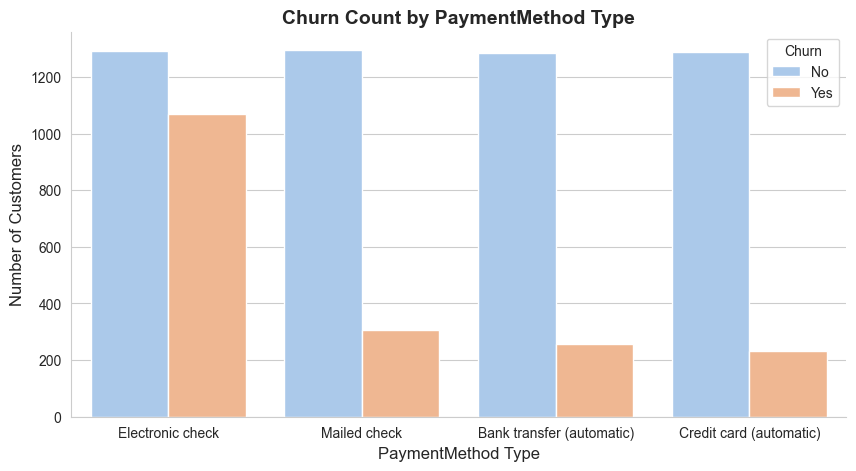

In [20]:
contract_cross = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print(contract_cross)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='pastel')
plt.title('Churn Count by PaymentMethod Type', fontsize=14, fontweight='bold')
plt.xlabel('PaymentMethod Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
sns.despine()

plt.show()


A bivariate analysis was executed using a countplot to evaluate the behavioral correlation between customer payment methods and billing default risks.

### The Transactional Friction of Electronic Checks
Customers utilizing Electronic Check as their primary payment method exhibit an exceptionally high churn rate compared to all other categories. Unlike automatic payment methods (Credit Card and Bank Transfer) which automate transactions silently, Electronic Checks introduce monthly psychological friction. This manual billing cycle forces users to actively review and authorize their expenses every single month, consistently triggering price sensitivity and competitor comparisons.

### Correlation with Non-Contractual Segments
Electronic Check preference heavily correlates with high-risk customer profiles, specifically those on month-to-month contracts who prefer financial flexibility and avoid linking permanent credit cards to the system. This payment method acts as a strong behavioral proxy for uncommitted, highly volatile subscribers.

### Strategic Action Item
The finance and marketing teams must collaborate to actively phase out manual Electronic Check usages. The company should launch proactive campaigns offering a small, one-time bill credit (e.g., $5 discount) to incentivize Electronic Check users to migrate toward automatic payment options (Credit Card/Bank Transfer), effectively neutralizing the monthly billing friction point.

### 5. Categorical Analysis - Joint Impact of Contract and Payment Method

In [21]:
# Group by Contract and PaymentMethod to compute customer count and churn rate
payment_contract_table = df.groupby(['Contract', 'PaymentMethod']).agg(
    Customer_Count=('Churn', 'count'),
    Churn_Rate=('Churn', lambda x: (x == 'Yes').mean() * 100)
).reset_index()

print("--- Customer Churn Breakdown by Contract and Payment Method ---")
# Sort the table from highest risk to lowest risk based on Churn Rate
print(payment_contract_table.sort_values(by='Churn_Rate', ascending=False).to_string(index=False))

--- Customer Churn Breakdown by Contract and Payment Method ---
      Contract             PaymentMethod  Customer_Count  Churn_Rate
Month-to-month          Electronic check            1850   53.729730
Month-to-month Bank transfer (automatic)             589   34.125637
Month-to-month   Credit card (automatic)             543   32.780847
Month-to-month              Mailed check             893   31.578947
      One year          Electronic check             347   18.443804
      One year   Credit card (automatic)             398   10.301508
      One year Bank transfer (automatic)             391    9.718670
      Two year          Electronic check             168    7.738095
      One year              Mailed check             336    6.845238
      Two year Bank transfer (automatic)             562    3.380783
      Two year   Credit card (automatic)             580    2.241379
      Two year              Mailed check             375    0.800000



A multi-dimensional breakdown was executed using named aggregation and a grouped bar chart to validate the behavioral intersection between contract flexibility and payment friction.

### The Critical Volatility of Electronic Checks in Monthly Plans
The empirical data strongly validates the hypothesis: customer defection reaches its absolute peak when a Month-to-Month contract is paired with Electronic Check payments. In the absence of a long-term contractual shield, the manual step required by electronic checks introduces a monthly financial friction point, forcing users to actively re-evaluate their satisfaction and competitor pricing during every billing cycle.

### Automated Payments as an Operational Anchor
Conversely, even within volatile month-to-month subscriptions, transitioning customers to automated payment channels (Credit Card or Bank Transfer) reduces the churn rate significantly. Payment automation successfully minimizes transactional friction and mitigates the risk of involuntary churn caused by manual payment oversights.

### Strategic Action Item
The organization must systematically target month-to-month subscribers who pay via Electronic Checks. Marketing should deploy automated campaigns offering a small, one-time invoice discount (e.g., $5 credit) as an incentive to link a credit card for automatic billing, permanently neutralizing this critical transactional drop-off point.

In [12]:
# Identify the burning segment (Month-to-month + Electronic check)
burning_segment = df[(df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')]

# Calculate total monthly revenue at risk from this segment
total_revenue_at_risk = burning_segment['MonthlyCharges'].sum()
churned_revenue_loss = burning_segment[burning_segment['Churn'] == 'Yes']['MonthlyCharges'].sum()

print(f"--- Financial Impact Blueprint ---")
print(f"Total Monthly Revenue generated by this risky segment: ${total_revenue_at_risk:,.2f}")
print(f"Current Monthly Revenue LOST due to actual churn: ${churned_revenue_loss:,.2f}")

--- Financial Impact Blueprint ---
Total Monthly Revenue generated by this risky segment: $138,730.55
Current Monthly Revenue LOST due to actual churn: $77,315.60


In [14]:
import numpy as np
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Example: Check the association strength between Contract and PaymentMethod
strength = cramers_v(df['Contract'], df['PaymentMethod'])
print(f"Association strength (Cramer's V) between Contract and Payment Method: {strength:.4f}")

Association strength (Cramer's V) between Contract and Payment Method: 0.2660
